# Grad-CAM localization analysis

All radio RGB cutouts and Grad-CAM maps are **resized to 150×150** before metrics (see `cam_attention_metrics.py`).

- **Source mask (pseudo–ground truth):** pixels with grayscale flux above **mean + n·σ** of the patch (default **3σ**).
- **CAM activation:** top fraction of pixels by heatmap value; PR curves sweep that fraction (`CAM_TOP_FRACS` in the module).

**Input:** precomputed per-source metrics in `plot_data/attention_metrics_cache.csv` (built from `all_cam_output/**/cam_npz/*.npz` via `cam_attention_metrics.build_table`).


In [1]:
# ── Load precomputed attention metrics ───────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Works whether Jupyter is launched from the repo root or notebooks/.
_cwd = Path.cwd()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents)
     if (p / "plot_data").is_dir() and (p / "notebooks").is_dir()),
    _cwd,
)
sys.path.insert(0, str(REPO_ROOT / "src" / "utils"))
import cam_attention_metrics as cam

DATA_DIR  = REPO_ROOT / "plot_data"
PLOTS_DIR = DATA_DIR / "plots"
CACHE_CSV = DATA_DIR / "attention_metrics_cache.csv"

# Per-source metrics precomputed from the Grad-CAM .npz files. To rebuild from raw
# maps instead: rows = cam.build_table("/path/to/all_cam_output", n_sigma=3.0).
assert CACHE_CSV.is_file(), f"missing metrics cache: {CACHE_CSV}"
rows = cam.load_rows_csv(str(CACHE_CSV))

print("rows:", len(rows))
groups = sorted({r["group_key"] for r in rows})
print("groups:", len(groups))
for g in groups:
    print(" ", g)

rows: 24720
groups: 12
  BYOL · no spurious
  BYOL · spurious
  ConvNeXt-B · no spurious
  ConvNeXt-B · spurious
  ResNet50 · no spurious
  ResNet50 · spurious
  Swin-B · no spurious
  Swin-B · spurious
  VGG16 · no spurious
  VGG16 · spurious
  ViT-B/16 · no spurious
  ViT-B/16 · spurious


In [2]:
# Fixed legend serials (M1..M6) and high-contrast colors
# Note: `arch` here is the display name produced by `cam_attention_metrics.parse_npz_path()`.
MODEL_SERIAL = {
    "ConvNeXt-B": "M1",
    "BYOL": "M2",
    "VGG16": "M3",
    "Swin-B": "M4",
    "ResNet50": "M5",
    "ViT-B/16": "M6",
}

# Worst -> best combined accuracy
MODEL_COLOR = {
    "ViT-B/16": "#ff3b30",
    "ResNet50": "#ff9500",
    "Swin-B": "#ffcc00",
    "VGG16": "#34c759",
    "BYOL": "#0a84ff",
    "ConvNeXt-B": "#bf5af2",
}

# Legend order (top -> bottom): M1, M2, ..., M6
MODEL_ORDER_ARCH = ["ConvNeXt-B", "BYOL", "VGG16", "Swin-B", "ResNet50", "ViT-B/16"]



def group_to_arch(group_key: str) -> str:
    # group_key looks like: "<arch> · <spurious/no spurious>"
    return group_key.split(" · ")[0].strip()

## 1. Localization precision–recall (CAM threshold sweep)

For each top fraction of CAM activation, mean precision and recall vs the 3σ radio mask, averaged over all sources in each model group. Solid markers trace the PR curve.

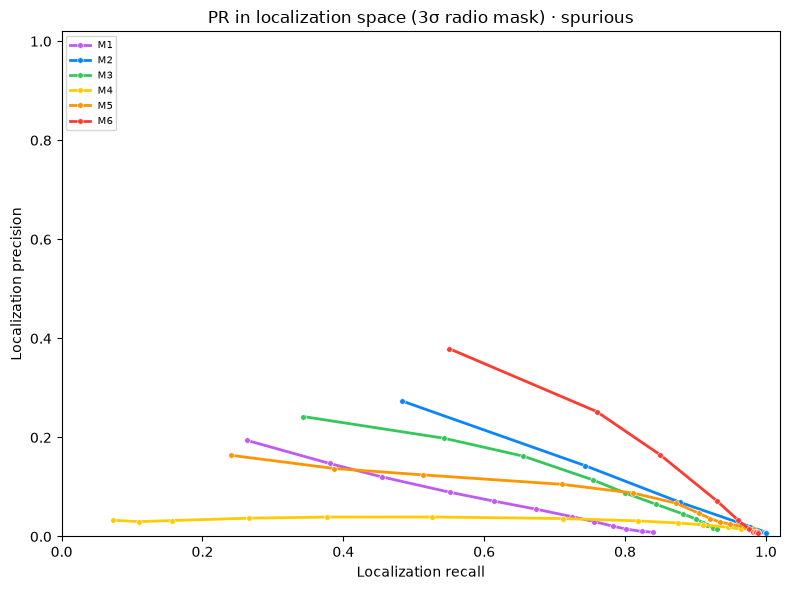

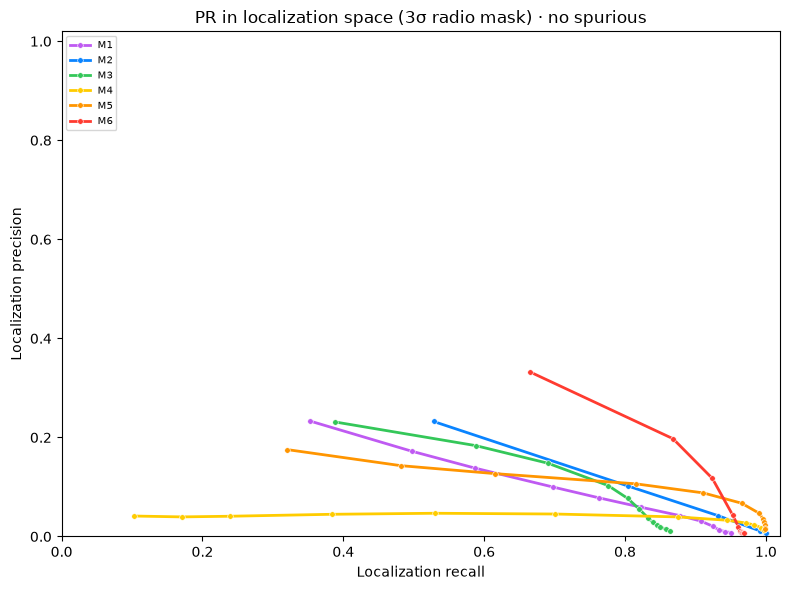

In [3]:
rows_sp = [r for r in rows if r["spurious"]]
rows_nosp = [r for r in rows if not r["spurious"]]


def _plot_pr_curves(rows_subset, sp_label: str):
    curves = cam.pr_curve_by_group(rows_subset)
    arch_curves: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for gk, (R, P) in curves.items():
        arch = group_to_arch(gk)
        arch_curves[arch] = (R, P)

    fig, ax = plt.subplots(figsize=(8, 6))
    for arch in MODEL_ORDER_ARCH:
        if arch not in arch_curves:
            continue
        R, P = arch_curves[arch]
        ax.plot(
            R,
            P,
            "-o",
            ms=4,
            lw=2.0,
            color=MODEL_COLOR[arch],
            label=MODEL_SERIAL[arch],
            mec="white",
            mew=0.4,
        )

    ax.set_xlabel("Localization recall")
    ax.set_ylabel("Localization precision")
    ax.set_title(f"PR in localization space (3σ radio mask) · {sp_label}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


_plot_pr_curves(rows_sp, "spurious")
_plot_pr_curves(rows_nosp, "no spurious")

## 2. Combined attention-metrics figure (no-spurious)

(a) SSIM CDF, (b) normalized-entropy CDF, and (c) CAM peak-distance vs spread, for all six models. Saved to `plot_data/plots/`.

/tmp/ipykernel_3628811/2482872081.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


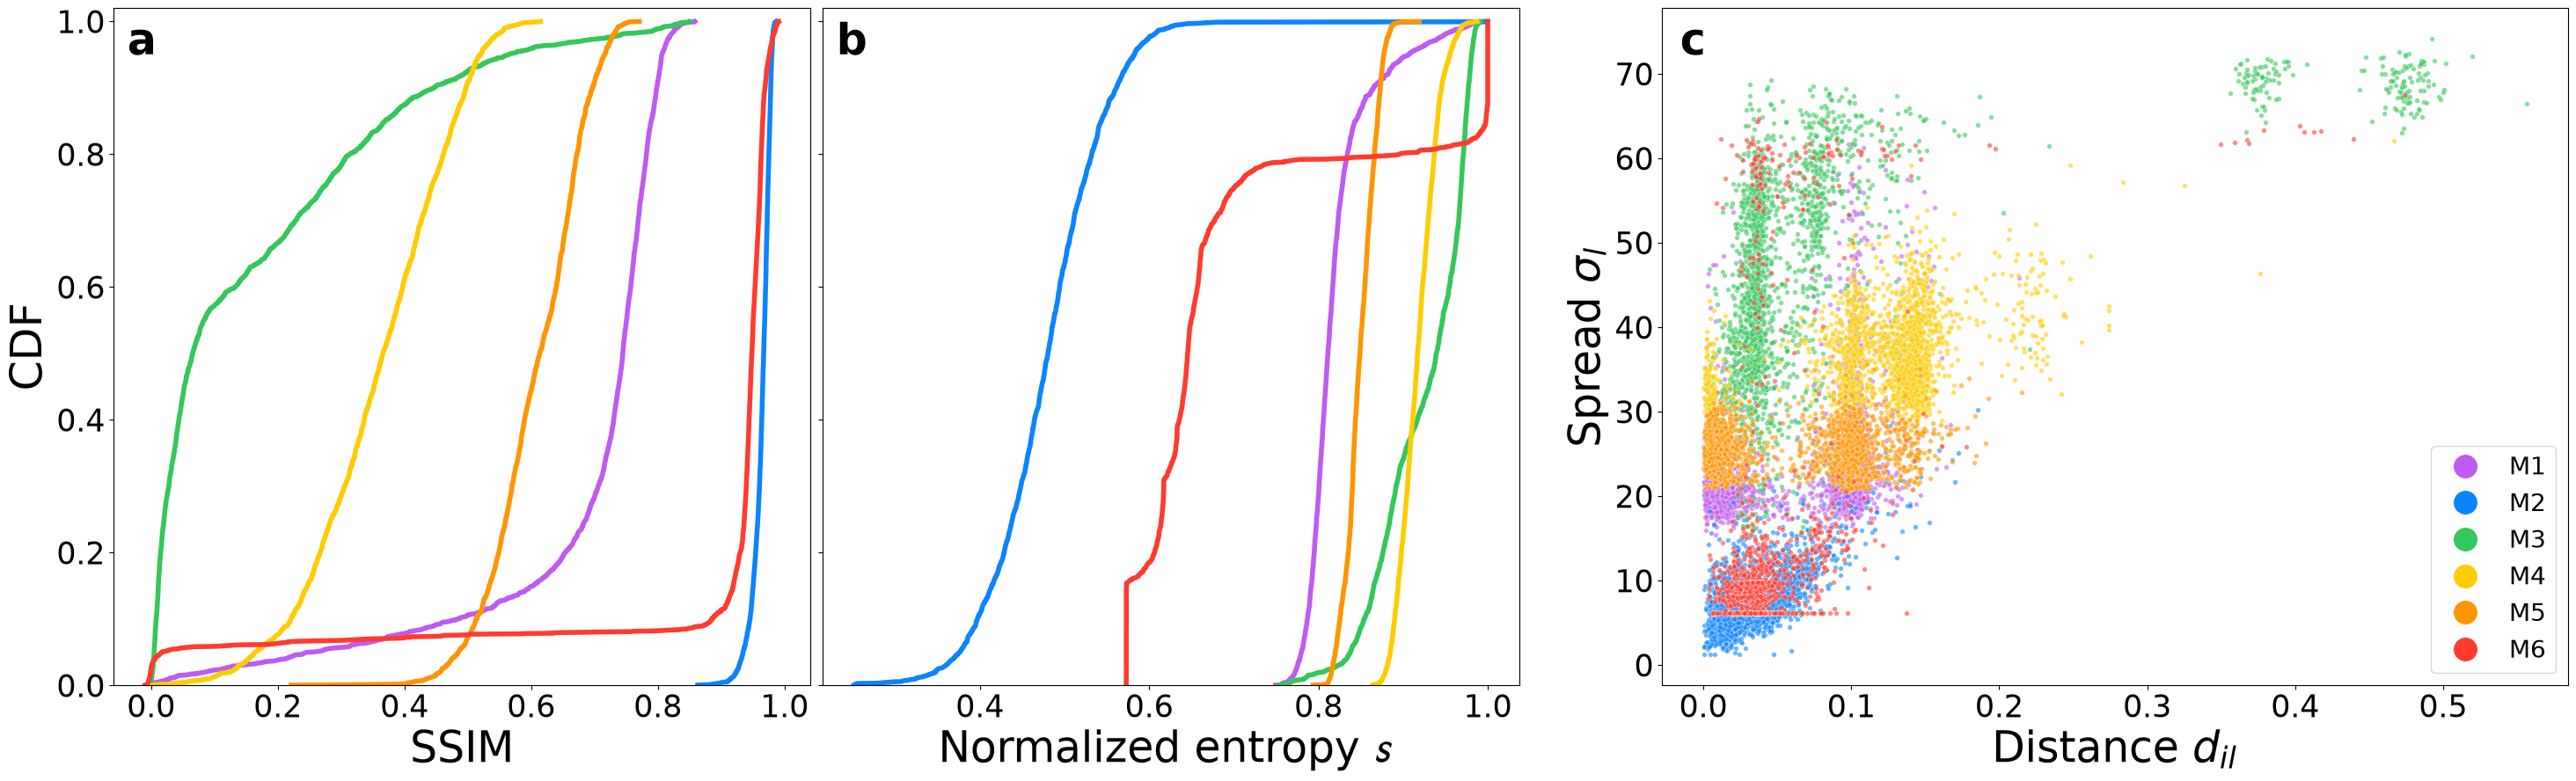

In [4]:
# Combined view (no-spurious only): panels a,b are CDFs with shared y-axis; panel c is distance vs spread
big_font = 35
medium_font = 25
small_font = 21
rows_nosp = [r for r in rows if not r["spurious"]]

fig = plt.figure(figsize=(30, 10))
# 4 columns: [a][b][gap][c] so a and b are attached; gap separates c
gs = fig.add_gridspec(nrows=1, ncols=4, width_ratios=[1, 1, 0.17, 1.3], wspace=0.02)

ax_ssim = fig.add_subplot(gs[0, 0])
ax_ent = fig.add_subplot(gs[0, 1], sharey=ax_ssim)
ax_sc_nosp = fig.add_subplot(gs[0, 3])


def _vals_for_arch(rows_subset, arch, key):
    return [r[key] for r in rows_subset if r["arch"] == arch]


# --- Panel a: SSIM CDF (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    vals = np.asarray(_vals_for_arch(rows_nosp, arch, "ssim_hm_vs_radio_mask"), dtype=np.float64)
    if vals.size:
        x, y = cam.ecdf(vals)
        ax_ssim.plot(x, y, lw=4, color=MODEL_COLOR[arch], linestyle="-", label=MODEL_SERIAL[arch])

ax_ssim.set_xlabel("SSIM", fontsize=big_font    )
ax_ssim.set_ylabel("CDF", fontsize=big_font)
ax_ssim.tick_params(axis="both", which="major", labelsize=medium_font)
ax_ssim.set_ylim(0, 1.02)
ax_ssim.text(0.02, 0.98, "a", transform=ax_ssim.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")

# --- Panel b: Entropy CDF (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    vals = np.asarray(_vals_for_arch(rows_nosp, arch, "entropy_norm"), dtype=np.float64)
    if vals.size:
        x, y = cam.ecdf(vals)
        ax_ent.plot(x, y, lw=4, color=MODEL_COLOR[arch], linestyle="-", label=MODEL_SERIAL[arch])

ax_ent.set_xlabel( r"Normalized entropy $\mathcal{s}$ ", fontsize=big_font)
ax_ent.set_ylabel("")
ax_ent.tick_params(axis="x", which="major", labelsize=medium_font)
ax_ent.tick_params(labelleft=False)
ax_ent.set_ylim(0, 1.02)
ax_ent.text(0.02, 0.98, "b", transform=ax_ent.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")


# --- Panel c: Peak distance vs spread (no-spurious only) ---
for arch in MODEL_ORDER_ARCH:
    pts = [(r["peak_dist_norm"], r["spread_l2"]) for r in rows_nosp if r["arch"] == arch]
    if not pts:
        continue
    xs = np.asarray([p[0] for p in pts], dtype=np.float64)
    ys = np.asarray([p[1] for p in pts], dtype=np.float64)
    m = np.isfinite(xs) & np.isfinite(ys)

    ax_sc_nosp.scatter(
        xs[m],
        ys[m],
        s=16,
        alpha=0.6,
        color=MODEL_COLOR[arch],
        label=MODEL_SERIAL[arch],
        edgecolors="white",
        linewidths=0.35,
        zorder=3,
    )

ax_sc_nosp.set_xlabel(r"Distance $d_{il}$", fontsize=big_font)
ax_sc_nosp.set_ylabel(r"Spread $\sigma_{l}$", fontsize=big_font)
ax_sc_nosp.tick_params(axis="both", which="major", labelsize=medium_font)
ax_sc_nosp.text(0.02, 0.98, "c", transform=ax_sc_nosp.transAxes, va="top", ha="left", fontsize=big_font, fontweight="bold")

# Legend only on panel c (opaque markers)
from matplotlib.lines import Line2D

legend_handles = []
legend_labels = []
for arch in MODEL_ORDER_ARCH:
    if any(r["arch"] == arch for r in rows_nosp):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                markersize=20,
                markerfacecolor=MODEL_COLOR[arch],
                markeredgecolor="white",
                markeredgewidth=0.6,
                alpha=1.0,
            )
        )
        legend_labels.append(MODEL_SERIAL[arch])

ax_sc_nosp.legend(legend_handles, legend_labels, loc="lower right", fontsize=20, frameon=True)

plt.subplots_adjust(left=0.05, right=0.98)
plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / "fig6_gradcam.pdf", dpi=300)
plt.savefig(PLOTS_DIR / "fig6_gradcam.png", dpi=150)
plt.show()

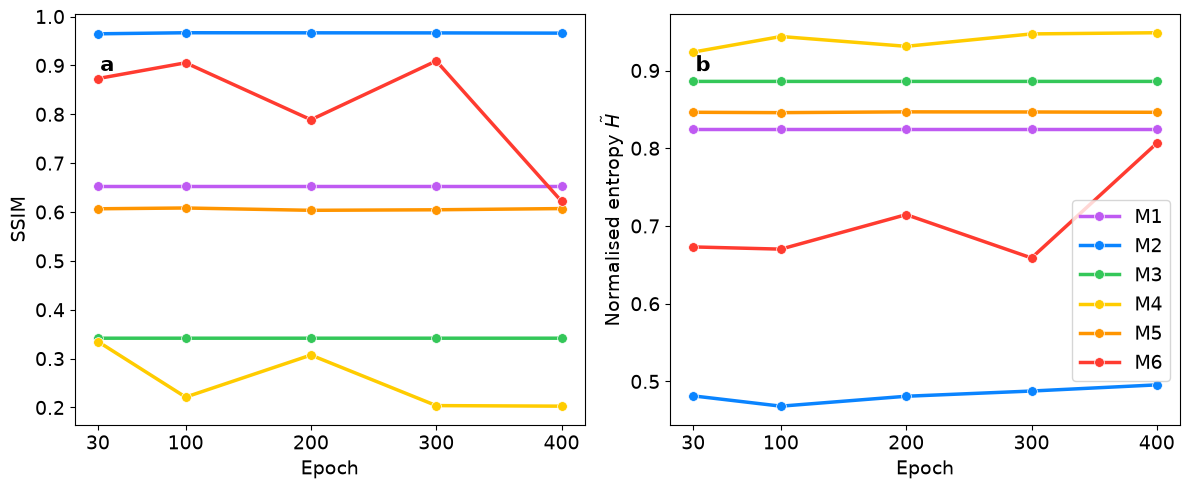

In [15]:
import csv
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
# main data in /media/aristotle/shahal/old/rgc_1/rgc_that_in_going_to_github/all_cam_output
# ── Config ────────────────────────────────────────────────────────────────────

CACHE_CSV = "/home/gate/rgc/plot_data/cache.csv"

EPOCHS = [30, 100, 200, 300, 400]

MODEL_SERIAL = {
    "ConvNeXt-B": "M1", "BYOL":     "M2", "VGG16":    "M3",
    "Swin-B":     "M4", "ResNet50": "M5", "ViT-B/16": "M6",
}
MODEL_COLOR = {
    "ViT-B/16":    "#ff3b30", "ResNet50":    "#ff9500", "Swin-B":     "#ffcc00",
    "VGG16":       "#34c759", "BYOL":        "#0a84ff", "ConvNeXt-B": "#bf5af2",
}
MODEL_ORDER_ARCH = ["ConvNeXt-B", "BYOL", "VGG16", "Swin-B", "ResNet50", "ViT-B/16"]

METRICS = ["ssim", "entropy_norm", "peak_dist_norm", "spread_l2", "prec20", "rec20"]

# ── Load cached metric table ──────────────────────────────────────────────────

def load_epoch_csv(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            row["epoch"] = int(row["epoch"])
            for k in ["ssim", "entropy_norm", "peak_dist_norm", "spread_l2", "prec20", "rec20"]:
                row[k] = float(row[k])
            rows.append(row)
    return rows

rows = load_epoch_csv(CACHE_CSV)

# ── Aggregate mean per (arch, epoch) ─────────────────────────────────────────

def aggregate(rows):
    acc = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for r in rows:
        for key in METRICS:
            v = r.get(key)
            if v is not None and np.isfinite(float(v)):
                acc[r["arch"]][r["epoch"]][key].append(float(v))
    return {
        arch: {
            epoch: {k: float(np.mean(vs)) for k, vs in by_key.items()}
            for epoch, by_key in by_epoch.items()
        }
        for arch, by_epoch in acc.items()
    }

agg = aggregate(rows)

# ── Plot: appendix 2-panel (SSIM + Normalised entropy) ───────────────────────

def plot_appendix(agg):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    panel_cfg = [
        ("ssim",         "SSIM",               True,  "a"),
        ("entropy_norm", r"Normalised entropy $\tilde{H}$", False, "b"),
    ]
    for ax, (key, ylabel, hib, pid) in zip(axes, panel_cfg):
        for arch in MODEL_ORDER_ARCH:
            if arch not in agg:
                continue
            xs = sorted(e for e in agg[arch] if key in agg[arch][e])
            ys = [agg[arch][e][key] for e in xs]
            if xs:
                ax.plot(xs, ys, "-o", lw=2.5, ms=7,
                        color=MODEL_COLOR[arch], label=MODEL_SERIAL[arch],
                        mec="white", mew=0.5)
        ax.set_xlabel("Epoch", fontsize=14)
        ax.set_ylabel(f"{ylabel}", fontsize=14)
        ax.set_xticks(EPOCHS)
        ax.tick_params(labelsize=14)
        ax.text(0.05, 0.90, pid, transform=ax.transAxes,
                va="top", ha="left", fontsize=15, fontweight="bold")

    handles, lbls = axes[0].get_legend_handles_labels()
    axes[1].legend(handles, lbls, fontsize=14, loc="upper right", bbox_to_anchor=(1.0, 0.57))
    plt.tight_layout()
    plt.savefig("../plot_data/plots/figD2_attention_epochs.pdf", dpi=300)
    plt.show()

plot_appendix(agg)